In [33]:
import mne

eye_open_raw_bdf = mne.io.read_raw_bdf("../dataset/open_UnicornRawDataRecorder_15_07_2026_16_04_18.bdf", preload=True)
eye_close_raw_bdf = mne.io.read_raw_bdf("../dataset/close_UnicornRawDataRecorder_15_07_2026_16_09_47.bdf", preload=True)

eye_close_raw_bdf.rename_channels(
    {
        "EXG 1": "Fz",
        "EXG 2": "C3",
        "EXG 3": "Cz",
        "EXG 4": "C4",
        "EXG 5": "Pz",
        "EXG 6": "PO7",
        "EXG 7": "POz",
        "EXG 8": "PO8",
    }
)

eye_open_raw_bdf.rename_channels(
    {
        "EXG 1": "Fz",
        "EXG 2": "C3",
        "EXG 3": "Cz",
        "EXG 4": "C4",
        "EXG 5": "Pz",
        "EXG 6": "PO7",
        "EXG 7": "POz",
        "EXG 8": "PO8",
    }
)

eye_close_raw_bdf.set_channel_types({"SATURATION": "misc","CNT": "misc","BAT": "misc","VALID": "misc", "DT": "misc",})
eye_open_raw_bdf.set_channel_types({"SATURATION": "misc","CNT": "misc","BAT": "misc","VALID": "misc", "DT": "misc",})

Extracting BDF parameters from ../dataset/open_UnicornRawDataRecorder_15_07_2026_16_04_18.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 76174  =      0.000 ...   304.696 secs...
Extracting BDF parameters from ../dataset/close_UnicornRawDataRecorder_15_07_2026_16_09_47.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 76450  =      0.000 ...   305.800 secs...


C:\Users\akila\AppData\Local\Temp\ipykernel_5548\769496517.py:32: RuntimeWarning: The unit for channel(s) BAT, CNT, DT, SATURATION, VALID has changed from V to NA.
  eye_close_raw_bdf.set_channel_types({"SATURATION": "misc","CNT": "misc","BAT": "misc","VALID": "misc", "DT": "misc",})
C:\Users\akila\AppData\Local\Temp\ipykernel_5548\769496517.py:33: RuntimeWarning: The unit for channel(s) BAT, CNT, DT, SATURATION, VALID has changed from V to NA.
  eye_open_raw_bdf.set_channel_types({"SATURATION": "misc","CNT": "misc","BAT": "misc","VALID": "misc", "DT": "misc",})


<RawBDF | open_UnicornRawDataRecorder_15_07_2026_16_04_18.bdf, 14 x 76175 (304.7 s), ~8.2 MiB, data loaded>

In [34]:
# ICA works best on high-pass filtered data (removes slow drifts that distort components)
# Keep a separate copy for the actual feature extraction if you want to compare pre/post

eye_open_filt = eye_open_raw_bdf.copy().filter(l_freq=1.0, h_freq=40.0, verbose=False)
eye_close_filt = eye_close_raw_bdf.copy().filter(l_freq=1.0, h_freq=40.0, verbose=False)

print("Filtering done: 1-40 Hz bandpass applied (copy, originals untouched)")

Filtering done: 1-40 Hz bandpass applied (copy, originals untouched)


In [39]:
# Apply standard electrode coordinates for plotting topomaps
eye_open_filt.set_montage("standard_1005")
eye_close_filt.set_montage("standard_1005")

<RawBDF | close_UnicornRawDataRecorder_15_07_2026_16_09_47.bdf, 14 x 76451 (305.8 s), ~8.2 MiB, data loaded>

In [40]:
from mne.preprocessing import ICA

# with 8 EEG channels, cap components conservatively (n_components <= n_channels)
N_ICA_COMPONENTS = 7

ica_open = ICA(n_components=N_ICA_COMPONENTS, method="fastica", random_state=RANDOM_STATE, max_iter="auto")
ica_open.fit(eye_open_filt, picks="eeg")

ica_close = ICA(n_components=N_ICA_COMPONENTS, method="fastica", random_state=RANDOM_STATE, max_iter="auto")
ica_close.fit(eye_close_filt, picks="eeg")

print("ICA fit complete for both conditions")

Fitting ICA to data using 8 channels (please be patient, this may take a while)
Selecting by number: 7 components
Fitting ICA took 0.2s.
Fitting ICA to data using 8 channels (please be patient, this may take a while)
Selecting by number: 7 components
Fitting ICA took 0.3s.
ICA fit complete for both conditions


Creating RawArray with float64 data, n_channels=7, n_times=76175
    Range : 0 ... 76174 =      0.000 ...   304.696 secs
Ready.


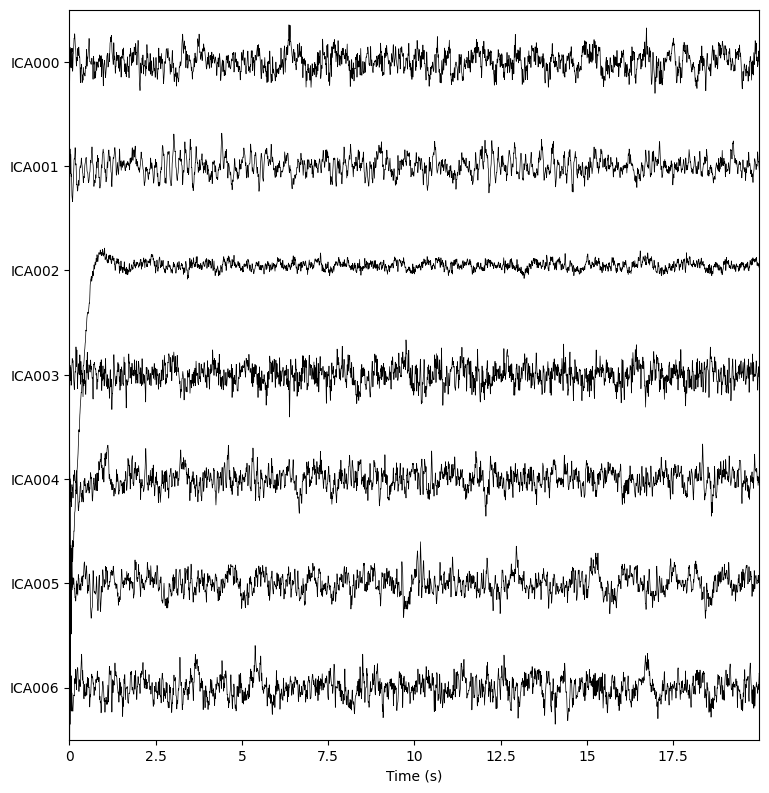

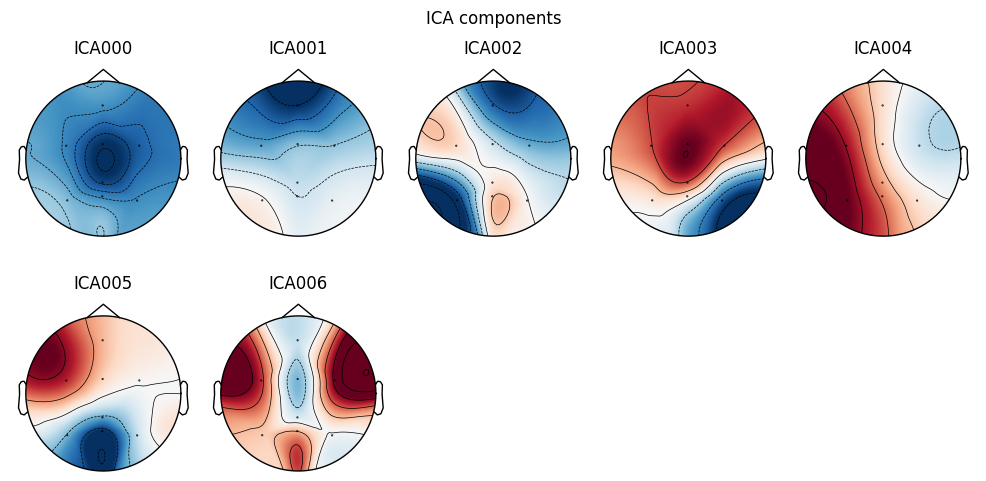

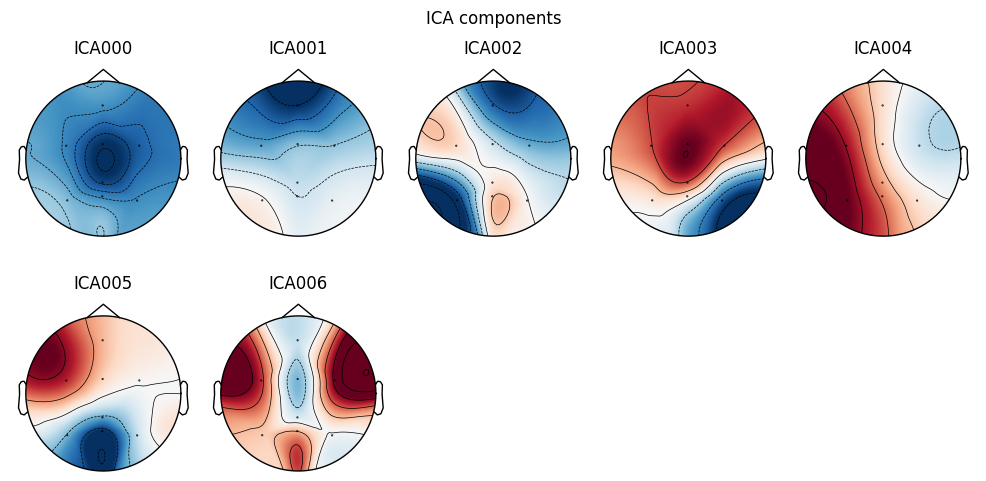

In [41]:
# component time courses + topomaps-equivalent (no digitization here, so use properties/scores instead)
ica_open.plot_sources(eye_open_filt, show_scrollbars=False)
ica_open.plot_components(inst=eye_open_filt)  # may fall back to a simplified view without montage/digitization

Eyes-open: candidate EOG components = []
Eyes-closed: candidate EOG components = []


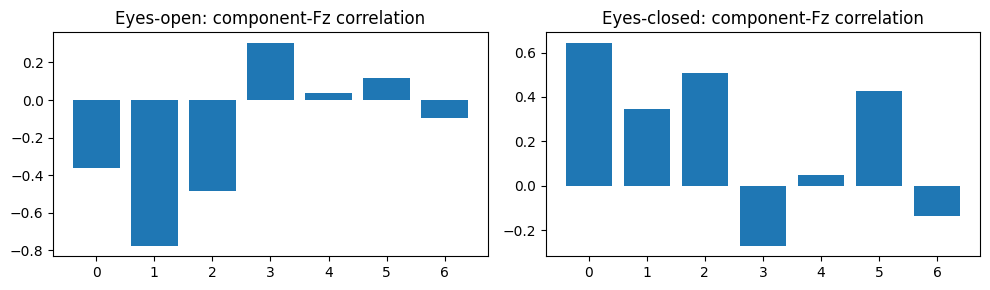

In [47]:
# no dedicated EOG channel, so use Fz (frontal, most eye-artifact-sensitive) as a proxy
eog_indices_open, eog_scores_open = ica_open.find_bads_eog(eye_open_filt, ch_name="Fz", verbose=False)
eog_indices_close, eog_scores_close = ica_close.find_bads_eog(eye_close_filt, ch_name="Fz", verbose=False)

print(f"Eyes-open: candidate EOG components = {eog_indices_open}")
print(f"Eyes-closed: candidate EOG components = {eog_indices_close}")

# plot correlation scores to sanity-check before excluding
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].bar(range(len(eog_scores_open)), eog_scores_open)
axes[0].set_title("Eyes-open: component-Fz correlation")
axes[1].bar(range(len(eog_scores_close)), eog_scores_close)
axes[1].set_title("Eyes-closed: component-Fz correlation")
plt.tight_layout()
plt.show()

In [48]:
# Manually exclude the frontal/blink component (ICA001) from eyes-open data
ica_open.exclude = [1] 

# Assuming eyes-closed doesn't have major blinks, leave it empty 
# (unless you spot a bad one in its plots too!)
ica_close.exclude = [] 

eye_open_clean = eye_open_filt.copy()
eye_close_clean = eye_close_filt.copy()

ica_open.apply(eye_open_clean)
ica_close.apply(eye_close_clean)

print(f"Removed component(s) {ica_open.exclude} from eyes-open")
print(f"Removed component(s) {ica_close.exclude} from eyes-closed")

Applying ICA to Raw instance
    Transforming to ICA space (7 components)
    Zeroing out 1 ICA component
    Projecting back using 8 PCA components
Applying ICA to Raw instance
    Transforming to ICA space (7 components)
    Zeroing out 0 ICA components
    Projecting back using 8 PCA components
Removed component(s) [1] from eyes-open
Removed component(s) [] from eyes-closed


In [49]:
EPOCH_DURATION = 0.5

epochs_open = mne.make_fixed_length_epochs(eye_open_clean, duration=EPOCH_DURATION, preload=True, overlap=0.0)
open_data = epochs_open.get_data(picks="eeg")

epochs_close = mne.make_fixed_length_epochs(eye_close_clean, duration=EPOCH_DURATION, preload=True, overlap=0.0)
close_data = epochs_close.get_data(picks="eeg")

sfreq = epochs_open.info["sfreq"]
ch_names = [eye_open_clean.ch_names[i] for i in mne.pick_types(eye_open_clean.info, eeg=True)]

print(f"open_data shape:  {open_data.shape}")
print(f"close_data shape: {close_data.shape}")
print(f"sfreq: {sfreq} Hz")
print(f"EEG channels: {ch_names}")

Not setting metadata
609 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 609 events and 125 original time points ...
0 bad epochs dropped
Not setting metadata
611 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 611 events and 125 original time points ...
0 bad epochs dropped
open_data shape:  (609, 8, 125)
close_data shape: (611, 8, 125)
sfreq: 250.0 Hz
EEG channels: ['Fz', 'C3', 'Cz', 'C4', 'Pz', 'PO7', 'POz', 'PO8']


In [50]:
import numpy as np
import pywt
from scipy.signal import welch
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, auc
import matplotlib.pyplot as plt

RANDOM_STATE = 42
BAND_LOW, BAND_HIGH = 7.0, 13.0
N_BLOCKS = 10

n_open = open_data.shape[0]
n_close = close_data.shape[0]
edges_open = np.linspace(0, n_open, N_BLOCKS + 1, dtype=int)
edges_close = np.linspace(0, n_close, N_BLOCKS + 1, dtype=int)

results = {}  # method_name -> list of fold accuracies

Fold 0: 0.967
Fold 1: 0.984
Fold 2: 0.967
Fold 3: 0.984
Fold 4: 0.975
Fold 5: 0.951
Fold 6: 0.975
Fold 7: 0.975
Fold 8: 0.943
Fold 9: 0.935

Bandpower (block-based): 0.966 +/- 0.016
Pooled ROC-AUC: 0.985


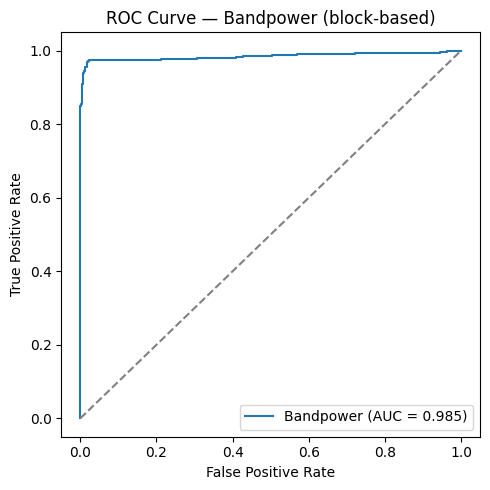

In [51]:
# --- compute bandpower features ONCE for all epochs (order preserved: open then close) ---
X_all = []
y_all = []
for data, label in [(open_data, 0), (close_data, 1)]:
    for e in range(data.shape[0]):
        feats = []
        for c in range(data.shape[1]):
            freqs, psd = welch(data[e, c, :], fs=sfreq, nperseg=min(256, data.shape[-1]))
            mask = (freqs >= BAND_LOW) & (freqs <= BAND_HIGH)
            feats.append(np.log1p(psd[mask].mean()))
        X_all.append(feats)
        y_all.append(label)

X_all = np.array(X_all)
y_all = np.array(y_all)

n_open = open_data.shape[0]
n_close = close_data.shape[0]
edges_open = np.linspace(0, n_open, N_BLOCKS + 1, dtype=int)
edges_close = np.linspace(n_open, n_open + n_close, N_BLOCKS + 1, dtype=int)  # offset into X_all

fold_accs_bandpower = []
y_true_all = []
y_proba_all = []

for fold in range(N_BLOCKS):
    test_idx = np.concatenate([
        np.arange(edges_open[fold], edges_open[fold + 1]),
        np.arange(edges_close[fold], edges_close[fold + 1]),
    ])
    train_idx = np.array([i for i in range(len(X_all)) if i not in set(test_idx)])

    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    scaler = StandardScaler().fit(X_train)
    clf = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE)
    clf.fit(scaler.transform(X_train), y_train)

    y_pred = clf.predict(scaler.transform(X_test))
    y_proba = clf.predict_proba(scaler.transform(X_test))[:, 1]

    acc = accuracy_score(y_test, y_pred)
    fold_accs_bandpower.append(acc)
    y_true_all.extend(y_test)
    y_proba_all.extend(y_proba)
    print(f"Fold {fold}: {acc:.3f}")

fold_accs_bandpower = np.array(fold_accs_bandpower)
results["Bandpower"] = fold_accs_bandpower
print(f"\nBandpower (block-based): {fold_accs_bandpower.mean():.3f} +/- {fold_accs_bandpower.std():.3f}")

y_true_all = np.array(y_true_all)
y_proba_all = np.array(y_proba_all)
fpr_bandpower, tpr_bandpower, _ = roc_curve(y_true_all, y_proba_all)
auc_bandpower = auc(fpr_bandpower, tpr_bandpower)
print(f"Pooled ROC-AUC: {auc_bandpower:.3f}")

plt.figure(figsize=(5, 5))
plt.plot(fpr_bandpower, tpr_bandpower, label=f"Bandpower (AUC = {auc_bandpower:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Bandpower (block-based)")
plt.legend()
plt.tight_layout()
plt.show()

Using DWT level 1 (62.50-125.00 Hz)
Fold 0: 0.934
Fold 1: 0.516
Fold 2: 0.746
Fold 3: 0.730
Fold 4: 0.705
Fold 5: 0.770
Fold 6: 0.689
Fold 7: 0.852
Fold 8: 0.803
Fold 9: 0.813

DWT (block-based): 0.756 +/- 0.106
Pooled ROC-AUC: 0.831


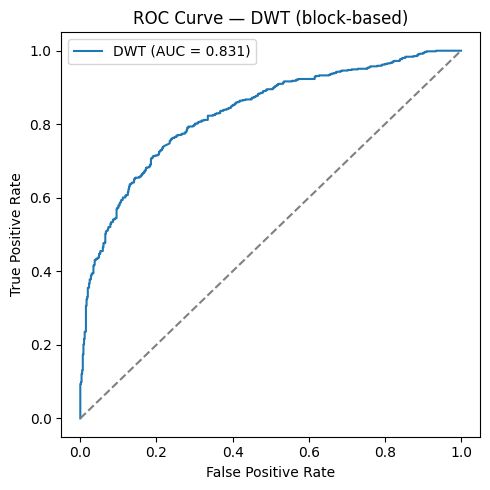

In [52]:
wavelet = "db6"
n_times = open_data.shape[-1]
nyquist = sfreq / 2.0
max_level = pywt.dwt_max_level(n_times, pywt.Wavelet(wavelet).dec_len)

best_level, best_overlap = 1, -1
for lvl in range(1, max_level + 1):
    f_lo = nyquist / (2 ** lvl)
    f_hi = nyquist / (2 ** (lvl - 1))
    overlap = min(f_hi, BAND_HIGH) - max(f_lo, BAND_LOW)
    if overlap > best_overlap:
        best_overlap, best_level = overlap, lvl
print(f"Using DWT level {best_level} ({nyquist/2**best_level:.2f}-{nyquist/2**(best_level-1):.2f} Hz)")

X_all = []
y_all = []
for data, label in [(open_data, 0), (close_data, 1)]:
    for e in range(data.shape[0]):
        feats = []
        for c in range(data.shape[1]):
            coeffs = pywt.wavedec(data[e, c, :], wavelet, level=max_level)
            detail = coeffs[max_level - best_level + 1]
            feats.append(np.log1p(np.sum(detail ** 2)))
        X_all.append(feats)
        y_all.append(label)

X_all = np.array(X_all)
y_all = np.array(y_all)

n_open = open_data.shape[0]
n_close = close_data.shape[0]
edges_open = np.linspace(0, n_open, N_BLOCKS + 1, dtype=int)
edges_close = np.linspace(n_open, n_open + n_close, N_BLOCKS + 1, dtype=int)

fold_accs_dwt = []
y_true_all = []
y_proba_all = []

for fold in range(N_BLOCKS):
    test_idx = np.concatenate([
        np.arange(edges_open[fold], edges_open[fold + 1]),
        np.arange(edges_close[fold], edges_close[fold + 1]),
    ])
    train_idx = np.array([i for i in range(len(X_all)) if i not in set(test_idx)])

    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    scaler = StandardScaler().fit(X_train)
    clf = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE)
    clf.fit(scaler.transform(X_train), y_train)

    y_pred = clf.predict(scaler.transform(X_test))
    y_proba = clf.predict_proba(scaler.transform(X_test))[:, 1]

    acc = accuracy_score(y_test, y_pred)
    fold_accs_dwt.append(acc)
    y_true_all.extend(y_test)
    y_proba_all.extend(y_proba)
    print(f"Fold {fold}: {acc:.3f}")

fold_accs_dwt = np.array(fold_accs_dwt)
results["DWT"] = fold_accs_dwt
print(f"\nDWT (block-based): {fold_accs_dwt.mean():.3f} +/- {fold_accs_dwt.std():.3f}")

y_true_all = np.array(y_true_all)
y_proba_all = np.array(y_proba_all)
fpr_dwt, tpr_dwt, _ = roc_curve(y_true_all, y_proba_all)
auc_dwt = auc(fpr_dwt, tpr_dwt)
print(f"Pooled ROC-AUC: {auc_dwt:.3f}")

plt.figure(figsize=(5, 5))
plt.plot(fpr_dwt, tpr_dwt, label=f"DWT (AUC = {auc_dwt:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — DWT (block-based)")
plt.legend()
plt.tight_layout()
plt.show()

Using 4 WPT nodes covering 5.86-13.67 Hz
Fold 0: 0.967
Fold 1: 1.000
Fold 2: 0.984
Fold 3: 1.000
Fold 4: 0.951
Fold 5: 1.000
Fold 6: 0.975
Fold 7: 1.000
Fold 8: 0.934
Fold 9: 0.935

WPT (block-based): 0.975 +/- 0.025
Pooled ROC-AUC: 0.991


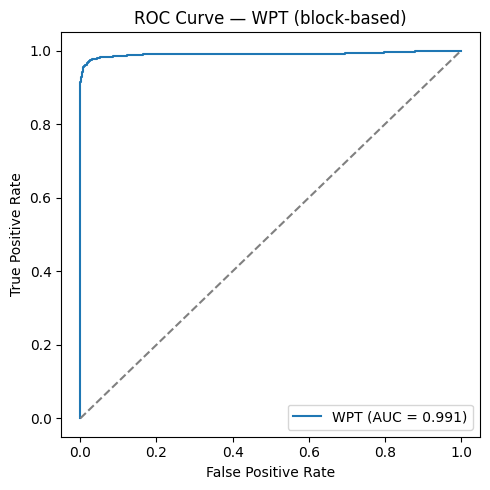

In [53]:
wavelet = "db6"
maxlevel = 6
n_nodes = 2 ** maxlevel
node_bandwidth = nyquist / n_nodes
node_idx_wpt = [i for i in range(n_nodes)
                if (i + 1) * node_bandwidth > BAND_LOW and i * node_bandwidth < BAND_HIGH]
print(f"Using {len(node_idx_wpt)} WPT nodes covering "
      f"{node_idx_wpt[0]*node_bandwidth:.2f}-{(node_idx_wpt[-1]+1)*node_bandwidth:.2f} Hz")

X_all = []
y_all = []
for data, label in [(open_data, 0), (close_data, 1)]:
    for e in range(data.shape[0]):
        feats = []
        for c in range(data.shape[1]):
            wp = pywt.WaveletPacket(data[e, c, :], wavelet, mode="symmetric", maxlevel=maxlevel)
            nodes = wp.get_level(maxlevel, order="freq")
            for i in node_idx_wpt:
                feats.append(np.log1p(np.sum(nodes[i].data ** 2)))
        X_all.append(feats)
        y_all.append(label)

X_all = np.array(X_all)
y_all = np.array(y_all)

n_open = open_data.shape[0]
n_close = close_data.shape[0]
edges_open = np.linspace(0, n_open, N_BLOCKS + 1, dtype=int)
edges_close = np.linspace(n_open, n_open + n_close, N_BLOCKS + 1, dtype=int)

fold_accs_wpt = []
y_true_all = []
y_proba_all = []

for fold in range(N_BLOCKS):
    test_idx = np.concatenate([
        np.arange(edges_open[fold], edges_open[fold + 1]),
        np.arange(edges_close[fold], edges_close[fold + 1]),
    ])
    train_idx = np.array([i for i in range(len(X_all)) if i not in set(test_idx)])

    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]

    scaler = StandardScaler().fit(X_train)
    clf = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE)
    clf.fit(scaler.transform(X_train), y_train)

    y_pred = clf.predict(scaler.transform(X_test))
    y_proba = clf.predict_proba(scaler.transform(X_test))[:, 1]

    acc = accuracy_score(y_test, y_pred)
    fold_accs_wpt.append(acc)
    y_true_all.extend(y_test)
    y_proba_all.extend(y_proba)
    print(f"Fold {fold}: {acc:.3f}")

fold_accs_wpt = np.array(fold_accs_wpt)
results["WPT"] = fold_accs_wpt
print(f"\nWPT (block-based): {fold_accs_wpt.mean():.3f} +/- {fold_accs_wpt.std():.3f}")

y_true_all = np.array(y_true_all)
y_proba_all = np.array(y_proba_all)
fpr_wpt, tpr_wpt, _ = roc_curve(y_true_all, y_proba_all)
auc_wpt = auc(fpr_wpt, tpr_wpt)
print(f"Pooled ROC-AUC: {auc_wpt:.3f}")

plt.figure(figsize=(5, 5))
plt.plot(fpr_wpt, tpr_wpt, label=f"WPT (AUC = {auc_wpt:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — WPT (block-based)")
plt.legend()
plt.tight_layout()
plt.show()

Method      Mean Acc    Std       
Bandpower   0.966       0.016     
DWT         0.756       0.106     
WPT         0.975       0.025     


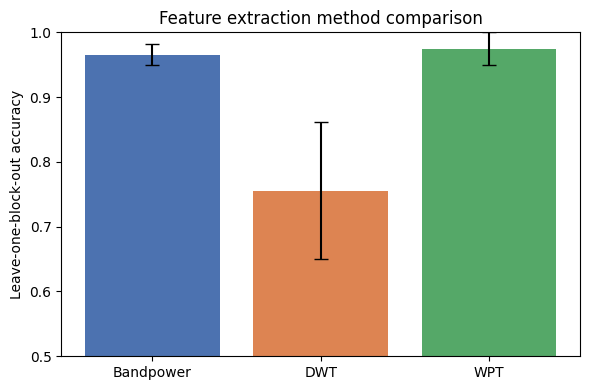

In [54]:
print(f"{'Method':<12}{'Mean Acc':<12}{'Std':<10}")
for name, accs in results.items():
    print(f"{name:<12}{accs.mean():<12.3f}{accs.std():<10.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
names = list(results.keys())
means = [results[n].mean() for n in names]
stds = [results[n].std() for n in names]
ax.bar(names, means, yerr=stds, capsize=5, color=["#4c72b0", "#dd8452", "#55a868"])
ax.set_ylabel("Leave-one-block-out accuracy")
ax.set_ylim(0.5, 1.0)
ax.set_title("Feature extraction method comparison")
plt.tight_layout()
plt.show()

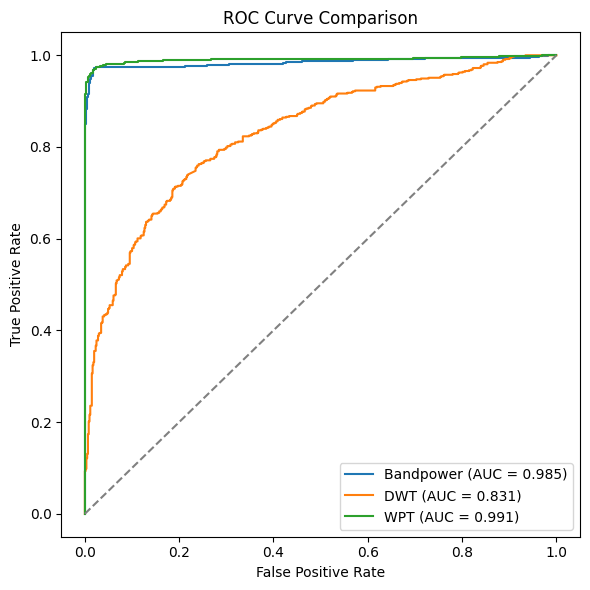

In [55]:
plt.figure(figsize=(6, 6))
plt.plot(fpr_bandpower, tpr_bandpower, label=f"Bandpower (AUC = {auc_bandpower:.3f})")
plt.plot(fpr_dwt, tpr_dwt, label=f"DWT (AUC = {auc_dwt:.3f})")
plt.plot(fpr_wpt, tpr_wpt, label=f"WPT (AUC = {auc_wpt:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

Some analysis on WPT coefficients

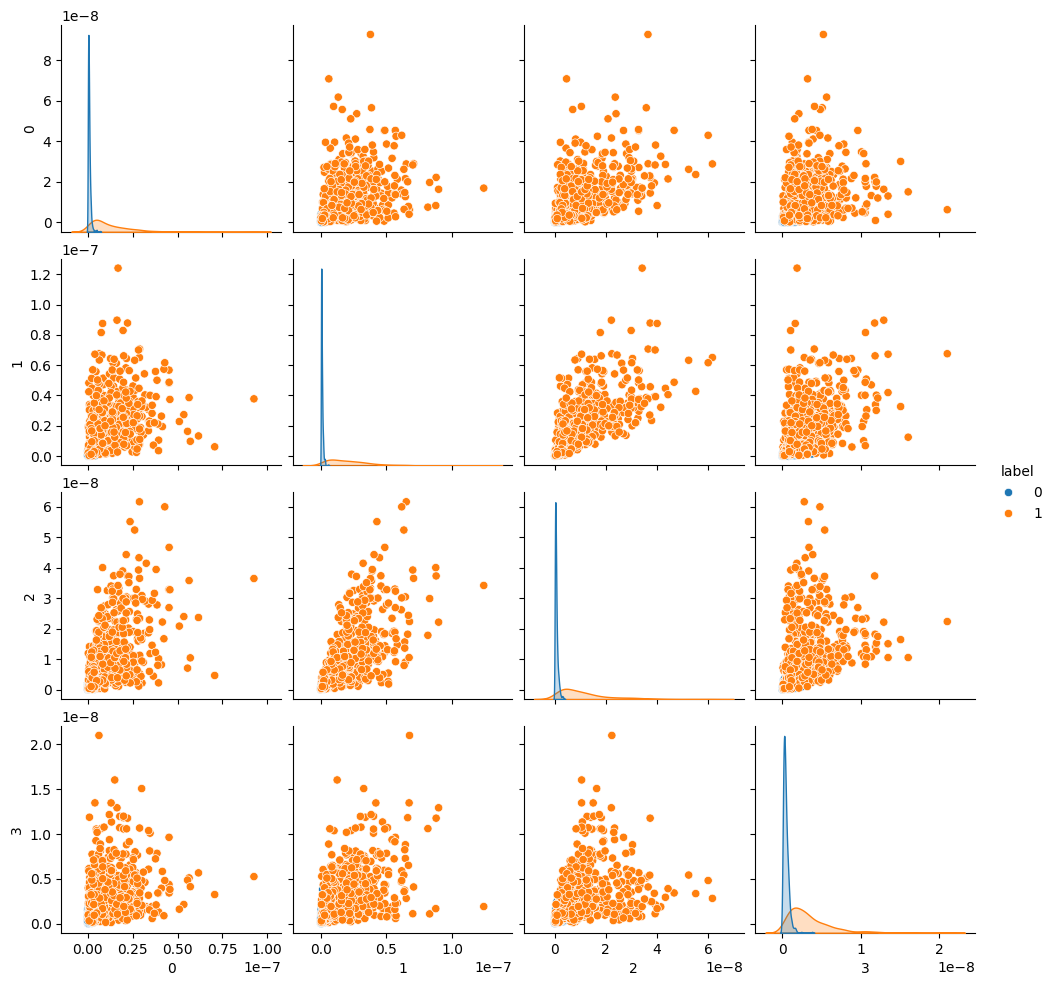

In [56]:
import pandas as pd
import seaborn as sns

X_all_df = pd.DataFrame(X_all)
X_all_df["label"] = y_all  # 0 = eyes open, 1 = eyes closed

cols_to_plot = list(X_all_df.columns[:4]) + ["label"]

sns.pairplot(X_all_df[cols_to_plot], hue="label")

Explained variance ratio per component: [0.51026246 0.08877862 0.06683067 0.05135036 0.04199774 0.03622722
 0.03349487 0.02276314 0.02048084 0.01677047 0.01508805]
Cumulative variance explained by first 2 PCs: 0.599


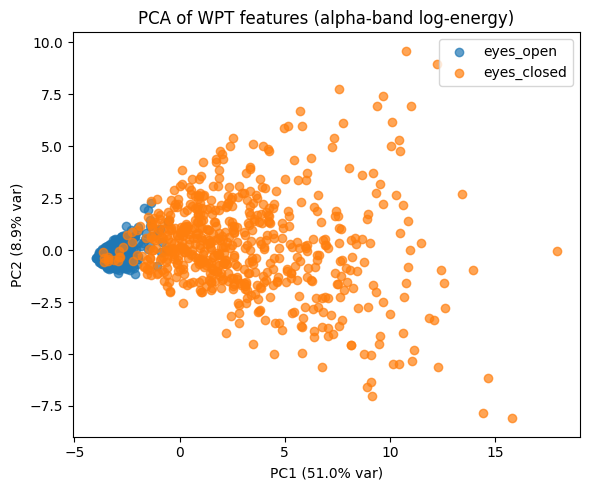

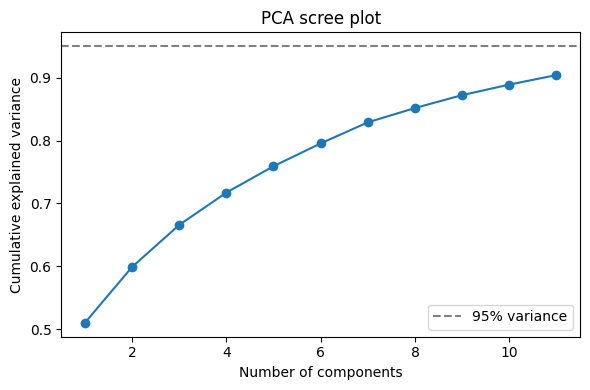

In [57]:
from sklearn.decomposition import PCA

# standardize before PCA (PCA is scale-sensitive, and your features are log-energies
# on different scales per channel/node)
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_all)

pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio per component:", pca.explained_variance_ratio_)
print("Cumulative variance explained by first 2 PCs: "
      f"{pca.explained_variance_ratio_[:2].sum():.3f}")

# --- 2D scatter of first two PCs ---
plt.figure(figsize=(6, 5))
labels_readable = pd.Series(y_all).map({0: "eyes_open", 1: "eyes_closed"})
for label in labels_readable.unique():
    mask = labels_readable == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=label, alpha=0.7)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA of WPT features (alpha-band log-energy)")
plt.legend()
plt.tight_layout()
plt.show()

# --- scree plot: how many components actually carry information ---
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA scree plot")
plt.axhline(0.95, linestyle="--", color="gray", label="95% variance")
plt.legend()
plt.tight_layout()
plt.show()

X_lda shape: (1220, 1)


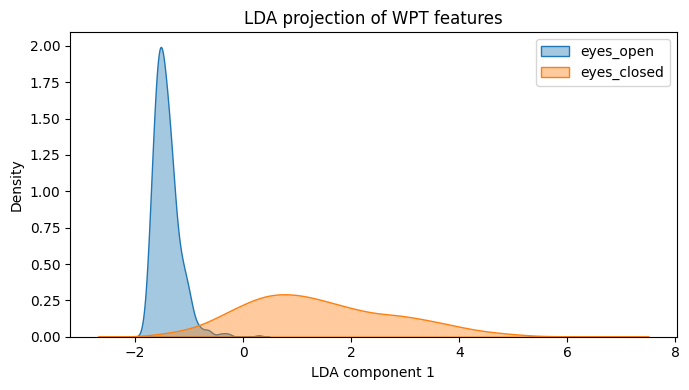

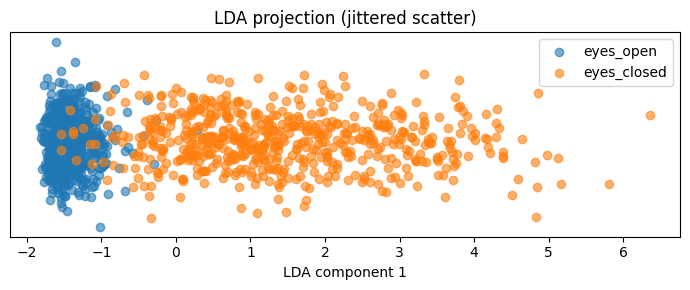

In [58]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# reuse the same scaled features from PCA
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_scaled, y_all)  # LDA is supervised - needs y_all

print(f"X_lda shape: {X_lda.shape}")  # (n_epochs, 1)

labels_readable = pd.Series(y_all).map({0: "eyes_open", 1: "eyes_closed"})

# --- 1D histogram / density plot ---
plt.figure(figsize=(7, 4))
for label in labels_readable.unique():
    mask = labels_readable == label
    sns.kdeplot(X_lda[mask, 0], label=label, fill=True, alpha=0.4)
plt.xlabel("LDA component 1")
plt.title("LDA projection of WPT features")
plt.legend()
plt.tight_layout()
plt.show()

# --- scatter with jitter, for a complementary view ---
plt.figure(figsize=(7, 3))
rng = np.random.RandomState(RANDOM_STATE)
jitter = rng.normal(0, 0.05, size=len(X_lda))
for label in labels_readable.unique():
    mask = labels_readable == label
    plt.scatter(X_lda[mask, 0], jitter[mask], label=label, alpha=0.6)
plt.xlabel("LDA component 1")
plt.yticks([])
plt.title("LDA projection (jittered scatter)")
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
# build feature names matching the X_all column order (channel-major, node-minor)
feature_names = [f"{ch}_node{i}" for ch in ch_names for i in node_idx_wpt]
assert len(feature_names) == X_all.shape[1]

X_all_df = pd.DataFrame(X_all, columns=feature_names)
print(ch_names)  # ['Fz', 'C3', 'Cz', 'C4', 'Pz', 'PO7', 'POz', 'PO8']

['Fz', 'C3', 'Cz', 'C4', 'Pz', 'PO7', 'POz', 'PO8']


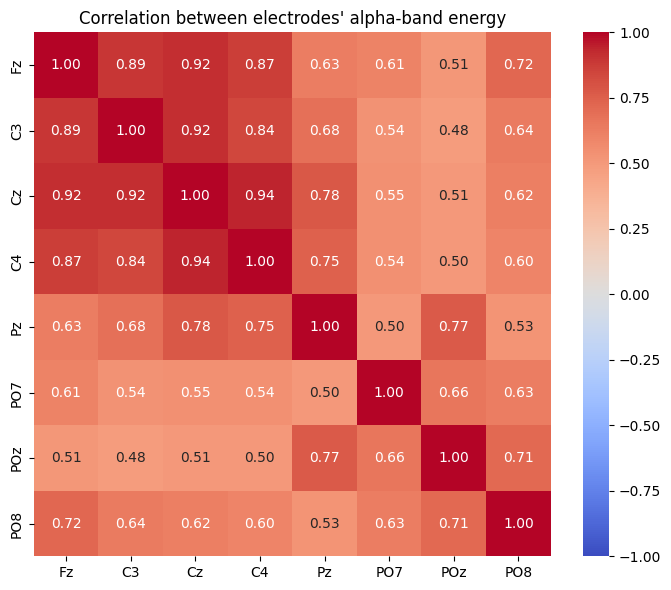

In [60]:
# average the 4 node-features per electrode into one summary value per epoch
electrode_summary = pd.DataFrame({
    ch: X_all_df[[c for c in feature_names if c.startswith(ch + "_")]].mean(axis=1)
    for ch in ch_names
})

plt.figure(figsize=(7, 6))
sns.heatmap(electrode_summary.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between electrodes' alpha-band energy")
plt.tight_layout()
plt.show()

Fz     0.0
C3     0.0
Cz     0.0
C4     0.0
Pz     0.0
PO7    0.0
POz    0.0
PO8    0.0
dtype: float64


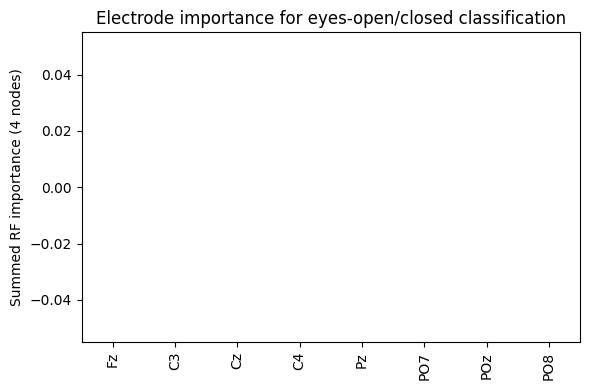

In [61]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE)
rf.fit(X_all_df, y_all)

importances = pd.Series(rf.feature_importances_, index=feature_names)

electrode_importance = pd.Series({
    ch: importances[[c for c in feature_names if c.startswith(ch + "_")]].sum()
    for ch in ch_names
}).sort_values(ascending=False)

print(electrode_importance)

plt.figure(figsize=(6, 4))
electrode_importance.plot(kind="bar")
plt.ylabel("Summed RF importance (4 nodes)")
plt.title("Electrode importance for eyes-open/closed classification")
plt.tight_layout()
plt.show()

In [62]:
# Check 1: Did the data become identical?
print("Is the data identical?", np.array_equal(open_data, close_data))

# Check 2: Did the data become flatlined zeros?
print("Max open value:", np.max(np.abs(open_data)))
print("Max close value:", np.max(np.abs(close_data)))

Is the data identical? False
Max open value: 0.0003484895572986608
Max close value: 0.0003909084906748995
